# AI Agent Demo

Minimal LangChain proof of concept that loads tools from the asyncroscopy MCP server and asks the model to use one or two of them. This will be useful to test our MCP server and new tools.

## Prereqs

Start the Tango stack on the microscope computer. Start MCP and the LLM device on the LLM computer. Both MCP and the LLM device use the microscope computer's Tango database:

```bash
uv run startup_scripts/run_servers.py
uv run startup_scripts/run_mcp.py --yaml configs/mcp.yaml
uv run startup_scripts/run_llm.py --yaml configs/gemma-llm.yaml
```

If not already done, install the optional AI extras:

```bash
uv sync --extra agent
# for local models do uv sync --extra agent --extra localagent
```

## Imports

In [46]:
import json
import os

import tango
from tiled.client import from_uri

## Ping Servers

In [47]:
MICROSCOPE_HOST = "10.46.217.241"
DB_PORT = 9094

os.environ["TANGO_HOST"] = f"{MICROSCOPE_HOST}:{DB_PORT}"
print(os.environ["TANGO_HOST"])

microscope = tango.DeviceProxy("asyncroscopy/instrument/default")
data = tango.DeviceProxy("asyncroscopy/data/default")
llm = tango.DeviceProxy("asyncroscopy/llm/default")

for proxy in (microscope, data, llm):
    proxy.set_timeout_millis(120_000)
    proxy.ping()
    print(proxy.name(), proxy.state())

tiled_config = json.loads(data.get_config())
client = from_uri(tiled_config["uri"])
print("Tiled:", tiled_config["uri"])

10.46.217.241:9094
asyncroscopy/instrument/default ON
asyncroscopy/data/default ON
asyncroscopy/llm/default ON
Tiled: http://10.46.217.241:9091


## Give a prompt

In [60]:
# adjust llm.max_steps if the LLM cannot complete a task
prompt = "Acquire an EDS spectrum."
response = llm.query(prompt)
print(response)

The EDS spectrum has been successfully acquired and saved as `spectrum_eds_20260731T165346932622.h5`.


In [61]:
client = from_uri("http://10.46.217.241:9091")
data_key = "spectrum_eds_20260731T165346932622.h5"

### Plot HAADF Images

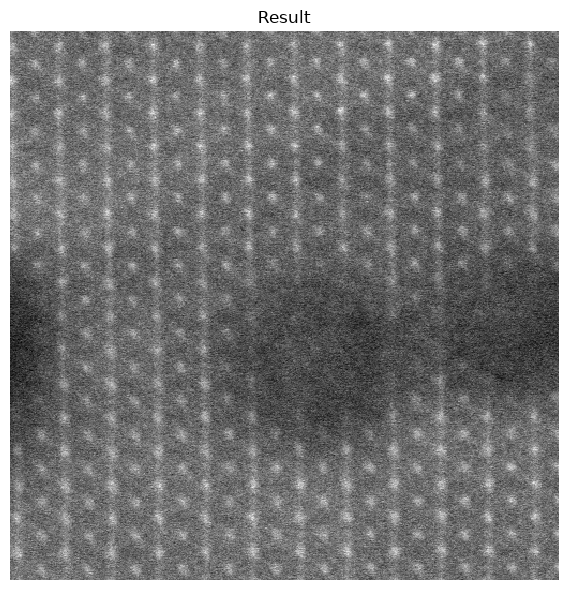

In [59]:
import matplotlib.pyplot as plt

image = client[data_key]["image"]["HAADF"].read()
metadata = dict(client[data_key]["image"]["HAADF"].metadata)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(image, cmap="gray", interpolation="none")
ax.set_title(f"Result")
ax.axis("off")
plt.tight_layout()

### Plot EDS Spectrum

Tiled key     : spectrum_eds_20260731T165346932622.h5
Metadata      : {'AccelerationVoltage': '200000', 'AcquisitionDatetime': '2026-07-31T20:53:46Z', 'AcquisitionStartDatetime': '2026-07-31T20:53:45Z', 'Alpha': '0.300076325', 'ApplicationSoftware': 'AutoScript TEM', 'ApplicationSoftwareVersion': '1.15.0.484', 'AzimuthAngle': '0.785398163', 'AzimuthAngle_140': '2.35619449', 'AzimuthAngle_156': '3.92699082', 'AzimuthAngle_172': '5.49778714', 'BeamConvergence': '0.0299593314', 'BeamDiameter': '0', 'Begin': '0', 'Begin_109': '0', 'Begin_117': '0.0728785469', 'Beta': '-0.0275172517', 'C1LensIntensity': '-0.451997334', 'C2LensIntensity': '0.194833341', 'C3LensIntensity': '0.351938644', 'CameraLength': '0.091', 'CollectionAngle': '0.7', 'CollectionAngle_141': '0.7', 'CollectionAngle_157': '0.7', 'CollectionAngle_173': '0.7', 'ComputerName': 'TITAN52340180', 'ControlSoftwareVersion': '3.21.1', 'DarkGainCorrectionType': 'DarkGain', 'DarkGainCorrectionType_202': 'DarkGain', 'DarkGainCorrectionT

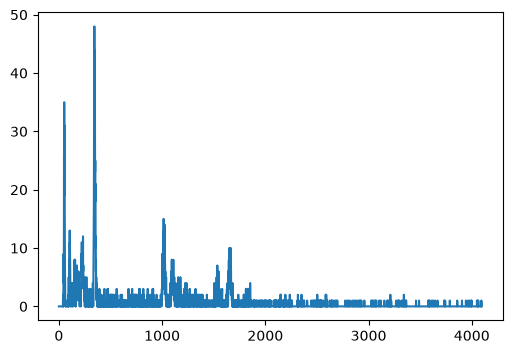

In [62]:
import numpy as np

node = client[data_key]["spectrum"]
spectrum = np.squeeze(np.asarray(node.read()))
metadata = dict(node.metadata)

print("Tiled key     :", data_key)
print("Metadata      :", metadata)
print("Spectrum shape:", spectrum.shape)
spectrum

plt.figure(figsize=(6, 4))
plt.plot(spectrum)
plt.show()